In [1]:

!apt-get update -q
!apt-get install -y wget unzip -q

!wget -q -O chrome.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i chrome.deb 2>/dev/null
!apt-get install -y -f -q
!pip install selenium webdriver-manager pandas matplotlib seaborn -q
print('Все ОК')

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,955 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,084 

Сиделка с проживанием и питанием | 110 000 — 125 000 ₽ на руки
Сиделка в пансионат проживанием без посредников | 95 000 — 125 000 ₽ на руки
Сиделку в пансионат для пожилых,с проживанием | 100 000 — 120 000 ₽ на руки
Сиделка с проживанием Вахта | от 150 000 ₽
Сиделка с проживанием (Москва) | 3 100 ₽ за смену на руки
Сиделка с проживанием на дому | 75 000 — 120 000 ₽ на руки
Помощник в больницу с ежедневной оплатой смены | 3 000 — 6 500 ₽ за смену на руки
Помощник в больницу ежедневные выплаты без опыта | 5 000 — 6 000 ₽ за смену на руки
Сиделка с проживанием и без / Помощь по уходу | от 100 000 ₽ на руки
Сиделка на дом | 75 000 — 85 000 ₽ на руки
Сиделка в пансионат вахта (18+) | 108 000 — 162 000 ₽ за смену на руки
Ищу Сиделку для своей бабушки | 95 000 — 125 000 ₽ на руки
Работа cиделкой в Москве | 65 000 — 85 000 ₽ на руки
Сиделка с проживанием | 70 000 — 130 000 ₽
Сиделка с проживанием вахта | 120 000 ₽ на руки
Сиделка вахтой в Москве с проживанием и питанием | от 100 000 ₽ на руки


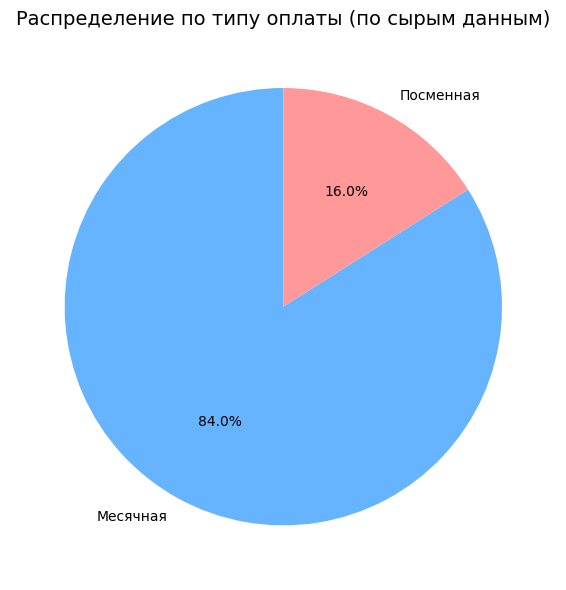

Месячная: 117,500 ₽ | Сиделка с проживанием и питанием
Месячная: 110,000 ₽ | Сиделка в пансионат проживанием без посредников
Месячная: 110,000 ₽ | Сиделку в пансионат для пожилых,с проживанием
Месячная: 150,000 ₽ | Сиделка с проживанием Вахта
Смена: 3,100 ₽/смену -> 62,000 ₽/мес | Сиделка с проживанием (Москва)
Месячная: 97,500 ₽ | Сиделка с проживанием на дому
Смена: 4,750 ₽/смену -> 95,000 ₽/мес | Помощник в больницу с ежедневной оплатой смены
Смена: 5,500 ₽/смену -> 110,000 ₽/мес | Помощник в больницу ежедневные выплаты без опыта
Месячная: 100,000 ₽ | Сиделка с проживанием и без / Помощь по уходу
Месячная: 80,000 ₽ | Сиделка на дом
Месячная: 135,000 ₽ | Сиделка в пансионат вахта (18+)
Месячная: 110,000 ₽ | Ищу Сиделку для своей бабушки
Месячная: 75,000 ₽ | Работа cиделкой в Москве
Месячная: 100,000 ₽ | Сиделка с проживанием
Месячная: 120,000 ₽ | Сиделка с проживанием вахта
Месячная: 100,000 ₽ | Сиделка вахтой в Москве с проживанием и питанием
Месячная: 82,500 ₽ | Сиделка к пожилому 

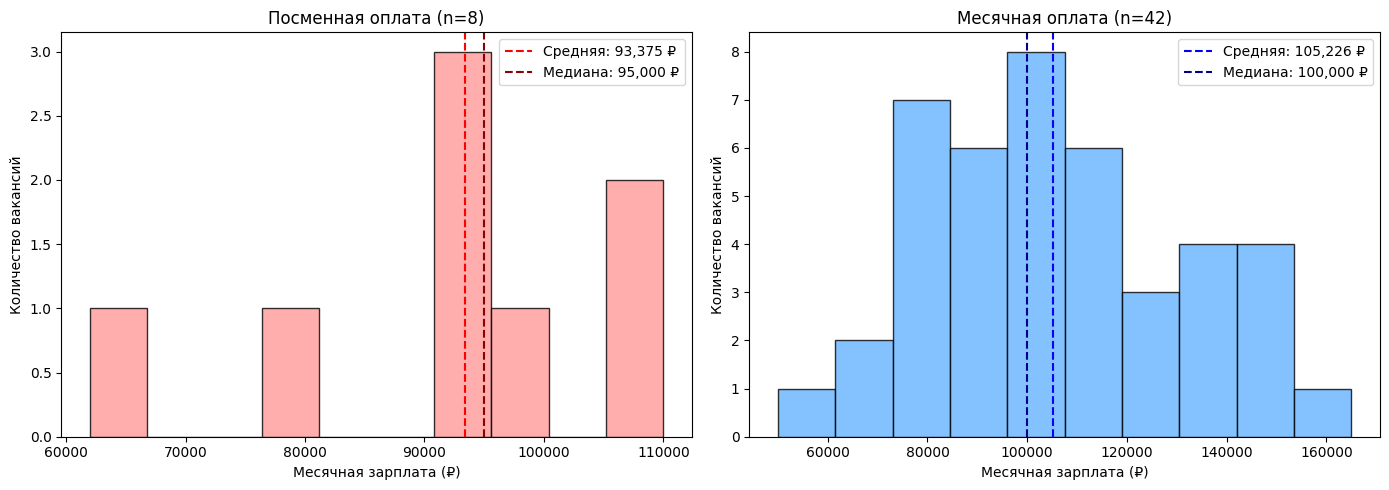


 Разброс посменной оплаты (после приведения к месячным):
Минимальная: 62000.0
Максимальная: 110000.0

 Разброс помесячной оплаты:
Минимальная: 50000.0
Максимальная: 165000.0
Для ВСЕХ зарплат по рынку в целом
Минимальная: 50000.0
Максимальная: 165000.0


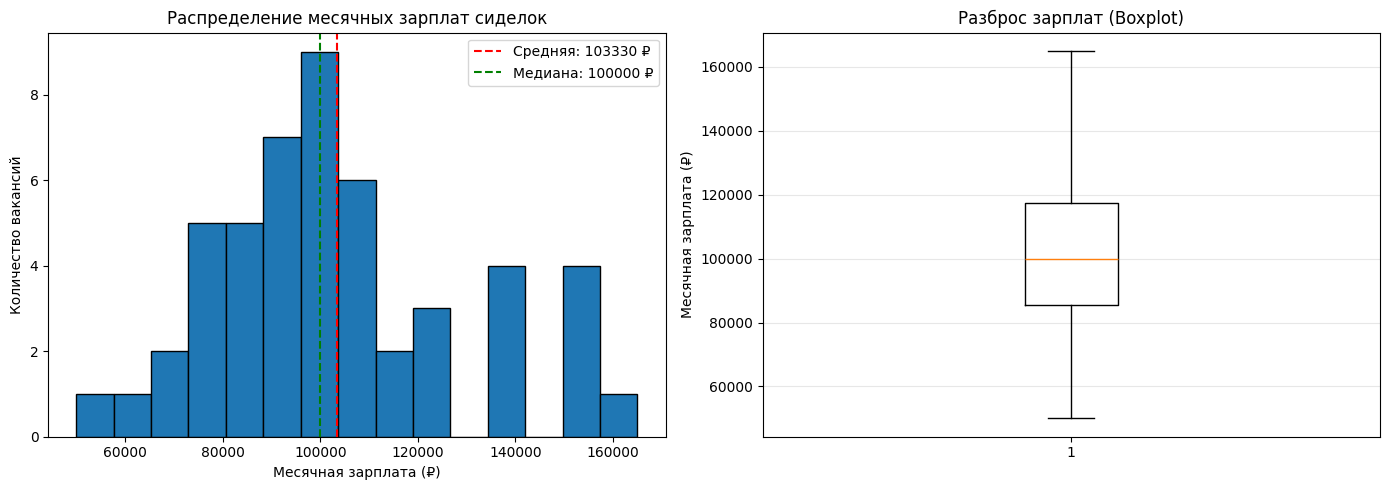

In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import time
import pandas as pd
import re
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.binary_location = "/usr/bin/google-chrome"

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.avito.ru/moskva/vakansii/tag/sidelka-s-prozhivaniem"
driver.get(url)
time.sleep(5)

for i in range(3):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

cards = driver.find_elements(By.CSS_SELECTOR, '[data-marker="item"]')

results = []
for card in cards[:50]:
    try:
        title = card.find_element(By.TAG_NAME, "h2").text

        salary = "Не указана"
        try:
            salary_elem = card.find_element(By.CSS_SELECTOR, '[data-marker="item-price"]')
            salary = salary_elem.text.strip()
        except:
            spans = card.find_elements(By.TAG_NAME, "span")
            for span in spans:
                if "₽" in span.text or "руб" in span.text:
                    salary = span.text.strip()
                    break

        results.append({
            "название": title,
            "зарплата_сырая": salary
        })
        print(f"{title} | {salary}")
    except Exception as e:
        continue

driver.quit()

if not results:
    print("Вакансии не найдены")
else:
    def normalize_salary_to_month(salary_text, title_text): #Хотим чтобы все зарплаты стали месячными
        if pd.isna(salary_text) or salary_text == "Не указана":
            return None, None, None

        text_salary = str(salary_text).lower()
        text_title = str(title_text).lower()
        combined_text = text_salary + " " + text_title

        numbers = re.findall(r'(\d[\d\s]*)', text_salary)
        numbers = [int(n.replace(' ', '')) for n in numbers if n.strip()]
        if not numbers:
            return None, None, None

        base_salary = None
        salary_from = None
        salary_to = None
        if len(numbers) == 1:
            base_salary = numbers[0]
        elif len(numbers) >= 2:
            salary_from = numbers[0]
            salary_to = numbers[1]
            base_salary = (salary_from + salary_to) / 2
        if base_salary is None:
            return None, None, None

        # Если зарплата за сутки (смену), то *5*4=*20 (5 рабочих дней в неделю 4 недели в месяц)
        if "ежедневные" in combined_text or "ежедневной" in combined_text or "ежедневно" in combined_text or base_salary <= 5000:
            monthly = base_salary * 20
            print(f"Смена: {base_salary:,.0f} ₽/смену -> {monthly:,.0f} ₽/мес | {title_text}")
            if salary_from and salary_to:
                return salary_from * 20, salary_to * 20, monthly
            return None, None, monthly

        print(f"Месячная: {base_salary:,.0f} ₽ | {title_text}")
        return salary_from, salary_to, base_salary


    df = pd.DataFrame(results)

    #Была функция по нормализации, а эта функция, наоборот вычисляет долю рынка посменной оплаты
    def detect_payment_type_from_raw(salary_raw):
        if pd.isna(salary_raw) or salary_raw == "Не указана":
            return "Не указана"
        numbers = re.findall(r'(\d[\d\s]*)', str(salary_raw))
        if not numbers:
            return "Не указана"
        salary_value = int(numbers[0].replace(' ', ''))
        if salary_value < 15000:
            return "Посменная"
        return "Месячная"

    df['тип_оплаты'] = df['зарплата_сырая'].apply(detect_payment_type_from_raw)
    type_counts = df['тип_оплаты'].value_counts()
    shift_count = len(df[df['тип_оплаты'] == "Посменная"])
    fig2, ax = plt.subplots(figsize=(8, 6))
    type_counts_filtered = type_counts[type_counts.index != "Не указана"]
    if len(type_counts_filtered) > 0:
        colors = ['#66b3ff', '#ff9999']
        type_counts_filtered.plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=colors[:len(type_counts_filtered)], startangle=90)
        ax.set_title('Распределение по типу оплаты (по сырым данным)', fontsize=14)
        ax.set_ylabel('')
        plt.tight_layout()
        plt.savefig('payment_types.png', dpi=100, bbox_inches='tight')#Сохраняем на всякий случай
        plt.show()


    normalized = df.apply(
      lambda row: normalize_salary_to_month(row['зарплата_сырая'], row['название']), axis=1
    )#кортеж для каждой вакансии

    df['зарплата_от_мес'] = [n[0] for n in normalized]
    df['зарплата_до_мес'] = [n[1] for n in normalized]
    df['зарплата_средняя_мес'] = [n[2] for n in normalized]
    df.to_csv("vacancies_raw.csv", index=False, encoding="utf-8-sig")
    df_clean = df[df['зарплата_средняя_мес'].notna()]


    df_shift = df_clean[df['тип_оплаты'] == "Посменная"]
    df_monthly_clean = df_clean[df['тип_оплаты'] == "Месячная"]
    fig_comp, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Гистограмма для посменной
    if len(df_shift) > 0:
        ax1.hist(df_shift['зарплата_средняя_мес'], bins=10, color='#ff9999', edgecolor='black', alpha=0.8)
        ax1.axvline(df_shift['зарплата_средняя_мес'].mean(), color='red', linestyle='--',
                   label=f'Средняя: {df_shift["зарплата_средняя_мес"].mean():,.0f} ₽')
        ax1.axvline(df_shift['зарплата_средняя_мес'].median(), color='darkred', linestyle='--',
                   label=f'Медиана: {df_shift["зарплата_средняя_мес"].median():,.0f} ₽')
        ax1.set_xlabel('Месячная зарплата (₽)')
        ax1.set_ylabel('Количество вакансий')
        ax1.set_title(f'Посменная оплата (n={len(df_shift)})')
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, 'Нет данных по посменной оплате', ha='center', va='center')
        ax1.set_title('Посменная оплата')

    # Гистограмма для месячной
    if len(df_monthly_clean) > 0:
        ax2.hist(df_monthly_clean['зарплата_средняя_мес'], bins=10, color='#66b3ff', edgecolor='black', alpha=0.8)
        ax2.axvline(df_monthly_clean['зарплата_средняя_мес'].mean(), color='blue', linestyle='--',
                   label=f'Средняя: {df_monthly_clean["зарплата_средняя_мес"].mean():,.0f} ₽')
        ax2.axvline(df_monthly_clean['зарплата_средняя_мес'].median(), color='darkblue', linestyle='--',
                   label=f'Медиана: {df_monthly_clean["зарплата_средняя_мес"].median():,.0f} ₽')
        ax2.set_xlabel('Месячная зарплата (₽)')
        ax2.set_ylabel('Количество вакансий')
        ax2.set_title(f'Месячная оплата (n={len(df_monthly_clean)})')
        ax2.legend()

    plt.tight_layout()
    plt.savefig('salary_by_payment_type.png', dpi=100, bbox_inches='tight')#сохраняем график для двоих
    plt.show()

    if len(df_shift) > 0:
        print(f"\n Разброс посменной оплаты (после приведения к месячным):")
        print(f"Минимальная: {df_shift['зарплата_средняя_мес'].min()}")
        print(f"Максимальная: {df_shift['зарплата_средняя_мес'].max()}")

    if len(df_monthly_clean) > 0:
        print(f"\n Разброс помесячной оплаты:")
        print(f"Минимальная: {df_monthly_clean['зарплата_средняя_мес'].min()}")
        print(f"Максимальная: {df_monthly_clean['зарплата_средняя_мес'].max()}")

    print('Для ВСЕХ зарплат по рынку в целом')
    if len(df_clean) > 0:
        print(f"Минимальная: {df_clean['зарплата_средняя_мес'].min()}")
        print(f"Максимальная: {df_clean['зарплата_средняя_мес'].max()}")


        q1 = df_clean['зарплата_средняя_мес'].quantile(0.25)
        q2 = df_clean['зарплата_средняя_мес'].quantile(0.5)
        q3 = df_clean['зарплата_средняя_мес'].quantile(0.75)


        bins = [0, 40000, 50000, 60000, 70000, 80000, 100000, 200000]
        labels = ['до 40к', '40-50к', '50-60к', '60-70к', '70-80к', '80-100к', '100к+']
        df_clean['salary_range'] = pd.cut(df_clean['зарплата_средняя_мес'], bins=bins, labels=labels)
        range_counts = df_clean['salary_range'].value_counts().sort_index()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))


        axes[0].hist(df_clean['зарплата_средняя_мес'], bins=15, edgecolor='black')
        axes[0].axvline(df_clean['зарплата_средняя_мес'].mean(), color='red', linestyle='--',
                       label=f'Средняя: {df_clean["зарплата_средняя_мес"].mean():.0f} ₽')
        axes[0].axvline(df_clean['зарплата_средняя_мес'].median(), color='green', linestyle='--',
                       label=f'Медиана: {df_clean["зарплата_средняя_мес"].median():.0f} ₽')
        axes[0].set_xlabel('Месячная зарплата (₽)')
        axes[0].set_ylabel('Количество вакансий')
        axes[0].set_title('Распределение месячных зарплат сиделок')
        axes[0].legend()


        axes[1].boxplot(df_clean['зарплата_средняя_мес'], vert=True)
        axes[1].set_ylabel('Месячная зарплата (₽)')
        axes[1].set_title('Разброс зарплат (Boxplot)')
        axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('salary_analysis.png', dpi=100, bbox_inches='tight')# сохранение графиков
        plt.show()


        recommended_min = int(df_clean['зарплата_средняя_мес'].quantile(0.50))  # медиана
        recommended_target = int(df_clean['зарплата_средняя_мес'].quantile(0.75))  # топ 25%

        summary = {
            'показатель': ['Всего_вакансий', 'С_указанием_зарплаты', 'Средняя_мес', 'Медиана_мес', 'Мин_мес', 'Макс_мес', 'Q1', 'Q3'],
            'значение': [
                len(df), len(df_clean),
                round(df_clean['зарплата_средняя_мес'].mean(), 0),
                round(df_clean['зарплата_средняя_мес'].median(), 0),
                round(df_clean['зарплата_средняя_мес'].min(), 0),
                round(df_clean['зарплата_средняя_мес'].max(), 0),
                round(q1, 0), round(q3, 0)
            ]
        }
        pd.DataFrame(summary).to_csv('salary_summary.csv', index=False, encoding='utf-8-sig')#засейвили основную дату

    else:
        print("Недостаточно данных для анализа")
